# Conversation Evaluation EDA

End-to-end analysis of the post-training conversation eval. Loads conversations + per-patient
scores from `data/`, runs the stat battery, plots the headline figures.

**Flow:** Setup → Load → Pick a selection (all / best per oracle) → Analyses.
Each analysis cell is independent; rerun any subset after picking a selection.

**Eval scoring** is a separate step — run [Run_Eval.ipynb](Run_Eval.ipynb) first if any model is missing eval CSVs.


## 1. Setup

One-shot import + plot style. Output cells below this point are independent and re-runnable.


In [1]:
from lib import (
    WORKSPACE_ROOT, ORACLE_METRIC_MAP, PlotContext, set_plot_style,
    EXPERIMENTS, get_model_names, get_model_eval_layout, resolve_paths,
    load_data, combine_data, add_model_metadata_columns, add_patient_characteristics,
    compute_model_order, apply_model_order, build_experiment_palette,
    load_all_eval_results, merge_q1_q2_results, build_test_cases,
    select_best_models_by_own_oracle, filter_to_models, build_merged_metrics,
    format_pvalue, iter_metric_cases, run_full_stats_battery,
    compare_all_vs_baseline, compare_all_pairwise, compare_lookahead,
    plot_metric_by_model, plot_subscales, plot_all_metrics_grid,
    plot_metrics_by_patient_characteristic, plot_correlation_heatmaps,
    plot_session_ending,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

set_plot_style()

## 2. Load Conversations + Eval Scores

Conversations and eval CSVs are loaded together so the rest of the notebook can mix-and-match.
After this cell: `combined_data`, `eval_results`, `test_cases`, `MODEL_ORDER`, `ctx`.


In [2]:
# ── Conversations ──
combined_data = combine_data(load_data(resolve_paths()), get_model_names())
combined_data["session_ended_by"] = combined_data["session_ended_by"].apply(
    lambda x: x if x in ["therapist", "patient"] else "None"
)
combined_data["id"] = combined_data["id"].astype(int)
combined_data = add_model_metadata_columns(combined_data)

MODEL_ORDER = compute_model_order(combined_data["Model"].astype(str).tolist())
combined_data = apply_model_order(combined_data, model_order=MODEL_ORDER)
combined_data = add_patient_characteristics(combined_data, id_col="id")

experiment_palette = build_experiment_palette(combined_data)
model_palette = {
    row["Model"]: experiment_palette.get(row["ExperimentGroup"], "gray")
    for _, row in combined_data[["Model", "ExperimentGroup"]].drop_duplicates().iterrows()
}
ctx = PlotContext(
    model_palette=model_palette,
    experiment_palette=experiment_palette,
    hue_col="ExperimentGroup",
    model_order=MODEL_ORDER,
)

# ── Eval scores ──
# Each model is read from its labelled folder (registry-derived root + oracle):
# data/<method>/eval_scores/metric=<M>/oracle=<O>/<model>/.
model_list = combined_data["Model"].astype(str).unique().tolist()
eval_results = load_all_eval_results(get_model_eval_layout(), model_list, MODEL_ORDER)
eval_results["Q1+Q2"] = merge_q1_q2_results(eval_results.get("Q1"), eval_results.get("Q2"))
if eval_results["Q1+Q2"] is not None:
    eval_results["Q1+Q2"] = apply_model_order(
        add_model_metadata_columns(eval_results["Q1+Q2"]), MODEL_ORDER
    )
test_cases = build_test_cases(eval_results, ORACLE_METRIC_MAP)

## 3. TL;DR

Quick orientation: what's loaded, headline mean per metric per group, and which iteration
wins each group's own oracle.


In [3]:
# What's loaded ─────────────────────────────────────────────────────
group_summary = combined_data.groupby("ExperimentGroup", observed=True).agg(
    conversations=("id", "size"),
    models=("Model", "nunique"),
)
display(
    group_summary.style.set_caption(
        f"Loaded {len(combined_data):,} conversations · "
        f"{combined_data['Model'].nunique()} models · "
        f"{combined_data['ExperimentGroup'].nunique()} groups · "
        f"{len(test_cases)} eval metrics"
    )
)

# Mean per metric per experiment group ────────────────────────────
rows = []
for name, df, col in test_cases:
    rows.append(df.groupby("ExperimentGroup", observed=True)[col].mean().rename(name))
headline = pd.concat(rows, axis=1)
display(headline.style.format("{:.3f}").background_gradient(cmap="Greens").set_caption(
    "Mean per metric × ExperimentGroup"
))


,conversations,models
ExperimentGroup,,
Base,96,1
L0_CSQ8,480,5
L0_Q1Q2,480,5
L0_WAI,480,5
L5_CSQ8,480,5
L5_Q1Q2,960,10
L5_WAI,480,5


,WAI-SR,CSQ-8,Q1+Q2,MI-SAT,MITI,Q1,Q2
ExperimentGroup,,,,,,,
Base,2.707,2.182,2.378,2.470,2.685,2.360,2.395
L0_CSQ8,2.716,2.211,2.496,2.517,2.747,2.481,2.510
L0_Q1Q2,2.774,2.293,2.643,2.635,2.898,2.629,2.656
L0_WAI,2.738,2.247,2.518,2.553,2.802,2.508,2.527
L5_CSQ8,2.723,2.226,2.513,2.549,2.773,2.490,2.537
L5_Q1Q2,2.925,2.373,2.812,2.739,3.086,2.781,2.842
L5_WAI,2.718,2.211,2.497,2.515,2.763,2.483,2.512


## 4. Pick a Selection

Run **one** of `4a` (all models, every iteration) or `4b` (best iteration per group, judged by
its own training oracle). Both produce: `selected_models`, `selected_test_cases`,
`selected_combined_data`, `selected_model_order`, `selection_label`.


### 4a. All Models — every iteration of every group

In [18]:
selected_models        = combined_data["Model"].astype(str).unique().tolist()
selected_test_cases    = test_cases
selected_combined_data = combined_data
selected_model_order   = MODEL_ORDER
selection_label        = f"All Models (n={len(selected_models)})"
print(selection_label)


All Models (n=36)


### 4b. Best per Group by Own Oracle

Each DPO group (e.g. `L0_WAI`) is judged by the questionnaire it was trained on.
GRPO_Exp3 is judged by Q1+Q2.


In [5]:
selected_models, own_oracle_summary = select_best_models_by_own_oracle(
    test_cases, ORACLE_METRIC_MAP,
)
selected_test_cases    = filter_to_models(test_cases, selected_models)
selected_combined_data = filter_to_models(combined_data, selected_models)
selected_model_order   = [m for m in MODEL_ORDER if m in set(selected_models)]
selection_label        = f"Best by Own Oracle (n={len(selected_models)})"

display(
    own_oracle_summary.style
    .format({"Mean": "{:.3f}", "Std": "{:.3f}"})
    .set_caption(selection_label)
)


,Metric,ExperimentGroup,BestModel,Mean,Std,N,LookAhead,OracleGroup,Iteration
0,CSQ-8,L0_CSQ8,L0_CSQ8_V5,2.255,1.244,96,0,CSQ8,5.000000
1,Q1+Q2,L0_Q1Q2,L0_Q1Q2_V5,2.770,1.197,96,0,Q1Q2,5.000000
2,WAI-SR,L0_WAI,L0_WAI_V5,2.788,1.167,96,0,WAI,5.000000
3,CSQ-8,L5_CSQ8,L5_CSQ8_V4,2.250,1.265,96,5,CSQ8,4.000000
4,Q1+Q2,L5_Q1Q2,L5_Q1Q2_V10,2.968,1.228,96,5,Q1Q2,10.000000
5,WAI-SR,L5_WAI,L5_WAI_V5,2.793,1.184,96,5,WAI,5.000000


## 5. Analyses

Each cell is independent — run any subset after picking a selection above.

**Reading the figures and tables:**
- **Bar heights** = mean score across 96 patient permutations.
- **Error bars** = 95% CI.
- **Dotted black line** = Base model mean.
- **Significance stars:** \* p<0.05, \*\* p<0.01, \*\*\* p<0.001.
- **Cohen's d:** <0.2 negligible, <0.5 small, <0.8 medium, ≥0.8 large.
- **η²:** >0.01 small, >0.06 medium, >0.14 large.
- **q_fdr:** BH-FDR adjusted p-value (significant if <0.05).


### 5.1 Metric Overview Grid

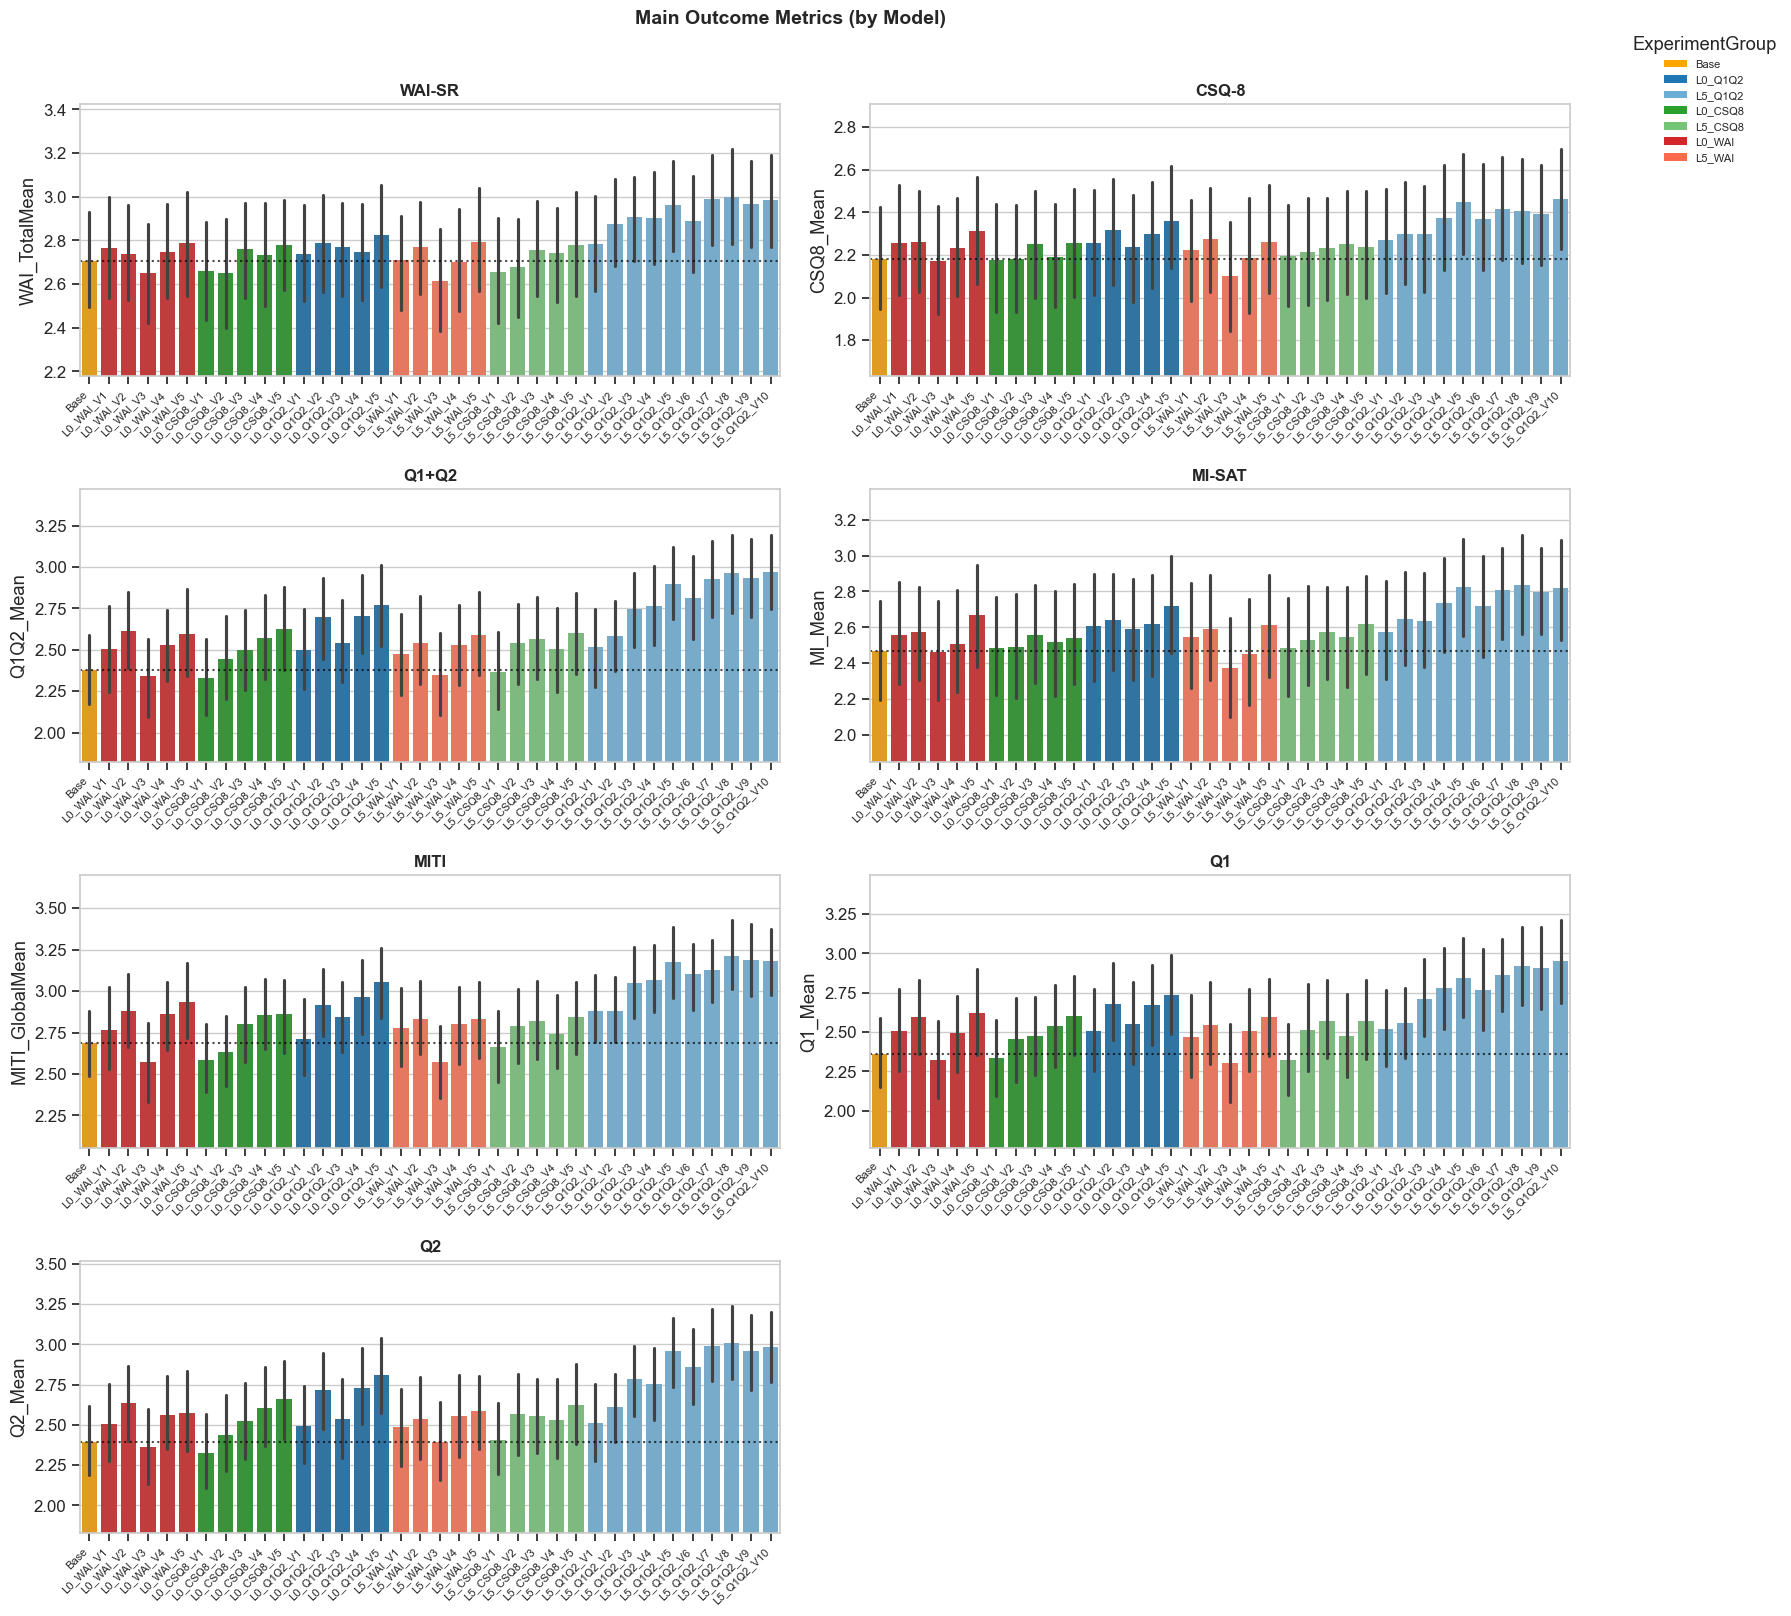

<Figure size 640x480 with 0 Axes>

In [19]:
plot_all_metrics_grid(
    selected_test_cases, group_by="Model",
    model_order=selected_model_order, ylim="auto", padding=0.25, ctx=ctx,
    figsize=(16, 16),
)
plt.suptitle(f"Metric Overview — {selection_label}", fontsize=14, fontweight="bold", y=1.01)
plt.show()


### 5.2 WAI-SR Subscales

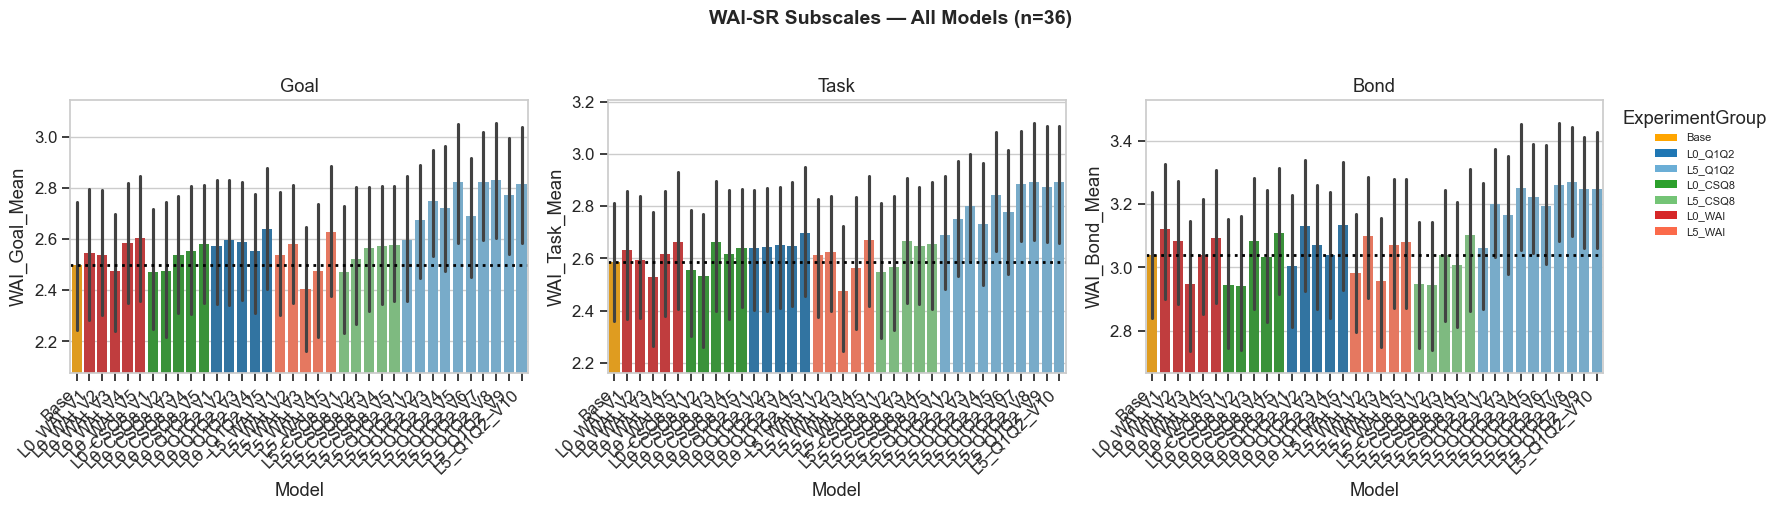

In [20]:
wai_df = eval_results.get("WAI-SR")
wai_models = {m for n, df, _ in selected_test_cases if n == "WAI-SR" and df is not None
              for m in df["Model"].astype(str).unique()}
if wai_df is not None and wai_models:
    plot_df = apply_model_order(wai_df[wai_df["Model"].isin(wai_models)].copy(), MODEL_ORDER)
    plot_subscales(
        plot_df,
        subscale_cols=["WAI_Goal_Mean", "WAI_Task_Mean", "WAI_Bond_Mean"],
        subscale_titles=["Goal", "Task", "Bond"],
        ylim="auto", suptitle=f"WAI-SR Subscales — {selection_label}",
        model_order=[m for m in selected_model_order if m in plot_df["Model"].unique()],
        ctx=ctx,
    )
else:
    print("WAI-SR data not available.")


### 5.3 MITI Subscales

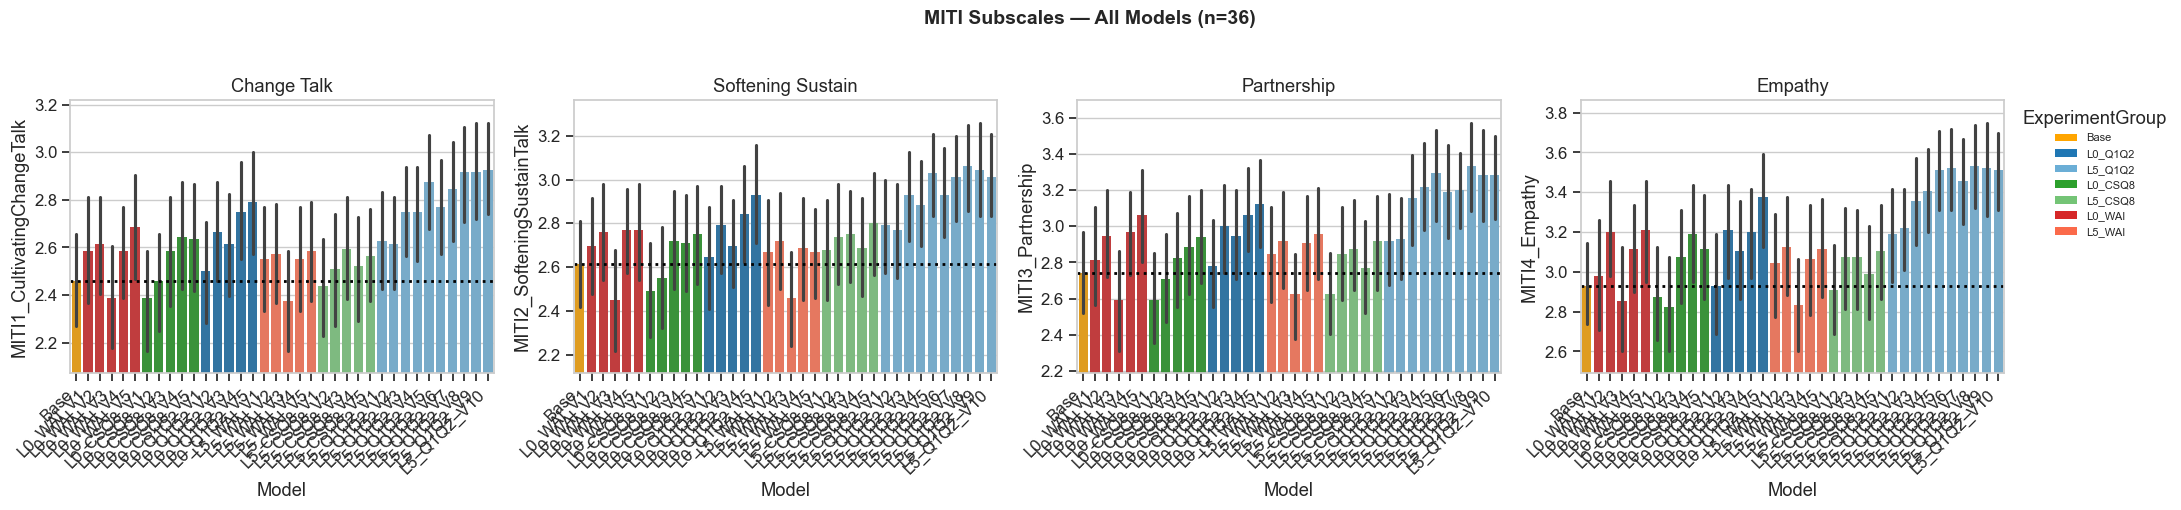

In [21]:
miti_df = eval_results.get("MITI")
miti_models = {m for n, df, _ in selected_test_cases if n == "MITI" and df is not None
               for m in df["Model"].astype(str).unique()}
if miti_df is not None and miti_models:
    plot_df = apply_model_order(miti_df[miti_df["Model"].isin(miti_models)].copy(), MODEL_ORDER)
    plot_subscales(
        plot_df,
        subscale_cols=["MITI1_CultivatingChangeTalk", "MITI2_SofteningSustainTalk",
                       "MITI3_Partnership", "MITI4_Empathy"],
        subscale_titles=["Change Talk", "Softening Sustain", "Partnership", "Empathy"],
        figsize=(22, 5), ylim="auto",
        suptitle=f"MITI Subscales — {selection_label}",
        model_order=[m for m in selected_model_order if m in plot_df["Model"].unique()],
        ctx=ctx,
    )
else:
    print("MITI data not available.")


### 5.4 Statistical Battery

Three layers: omnibus (any difference?) → vs Base (which models beat Base?) → pairwise.


#### 5.4a Omnibus — does any model differ within each metric?

In [22]:
stats_results = run_full_stats_battery(selected_test_cases, groupby_levels=["Model"], baseline="Base")

rows = []
for key, payload in stats_results.items():
    metric = key.rsplit("_", 1)[0]
    a = payload.get("anova") or {}
    k = payload.get("kruskal") or {}
    p_a = a.get("p_value", 1.0)
    rows.append({
        "Metric": metric,
        "F (ANOVA)":         a.get("F_statistic", float("nan")),
        "p-val (ANOVA)":     format_pvalue(p_a),
        "η²":                a.get("eta_squared", float("nan")),
        "H (Kruskal-Wallis)": k.get("H_statistic", float("nan")),
        "p-val (K-W)":       format_pvalue(k.get("p_value", 1.0)),
        "Sig?":              "✓" if p_a < 0.05 else "",
    })
if rows:
    display(
        pd.DataFrame(rows).set_index("Metric").style
        .format({"F (ANOVA)": "{:.2f}", "η²": "{:.3f}", "H (Kruskal-Wallis)": "{:.2f}"})
        .background_gradient(subset=["η²"], cmap="RdYlGn_r")
        .set_caption(f"5.4a Omnibus — {selection_label}")
    )


c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


,F (ANOVA),p-val (ANOVA),η²,H (Kruskal-Wallis),p-val (K-W),Sig?
Metric,,,,,,
WAI-SR,0.85,0.7261,0.009,36.85,0.3835,
CSQ-8,0.44,0.9982,0.005,28.31,0.7813,
Q1+Q2,2.10,1.65e-04 ***,0.021,97.88,7.34e-08 ***,✓
MI-SAT,0.67,0.9312,0.007,30.43,0.6886,
MITI,2.54,1.84e-06 ***,0.025,96.96,9.99e-08 ***,✓
Q1,1.78,0.0034 **,0.018,78.97,3.04e-05 ***,✓
Q2,2.44,5.11e-06 ***,0.024,104.82,6.85e-09 ***,✓


#### 5.4b Each Model vs Base — Mann-Whitney U + BH-FDR

In [23]:
vs_base = compare_all_vs_baseline(selected_test_cases, baseline="Base")
if vs_base.empty:
    print("No data for vs-baseline comparison.")
else:
    n_sig = int(vs_base["Significant"].sum())
    print(f"vs-Base: {n_sig}/{len(vs_base)} tests significant after BH-FDR (q < 0.05)")
    for metric in vs_base["Metric"].unique():
        sig = vs_base[(vs_base["Metric"] == metric) & vs_base["Significant"]].copy()
        if sig.empty:
            continue
        display(
            sig.drop(columns=["Metric", "Significant"]).reset_index(drop=True).style
            .format({
                "Mean": "{:.3f}", "Baseline_Mean": "{:.3f}", "Delta_Mean": "{:.3f}",
                "U": "{:.0f}", "p_raw": "{:.4f}", "q_fdr": "{:.4f}", "Cohens_d": "{:.3f}",
            })
            .set_caption(f"5.4b {metric} — {len(sig)} significant vs Base ({selection_label})")
        )


vs-Base: 23/245 tests significant after BH-FDR (q < 0.05)


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L5_Q1Q2_V5,96,3.177,2.685,0.492,5934,0.0005,0.0094,0.485,small
1,L5_Q1Q2_V8,96,3.211,2.685,0.526,5966,0.0004,0.0094,0.521,medium
2,L5_Q1Q2_V10,96,3.182,2.685,0.497,5848,0.0012,0.0128,0.499,small
3,L5_Q1Q2_V9,96,3.190,2.685,0.505,5826,0.0015,0.0128,0.493,small
4,L5_Q1Q2_V6,96,3.102,2.685,0.417,5715,0.0039,0.0225,0.405,small
5,L5_Q1Q2_V7,96,3.128,2.685,0.443,5720,0.0037,0.0225,0.448,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L5_Q1Q2_V10,96,2.950,2.360,0.590,5821,0.0015,0.0198,0.477,small
1,L5_Q1Q2_V5,96,2.844,2.360,0.483,5745,0.0028,0.0198,0.410,small
2,L5_Q1Q2_V7,96,2.865,2.360,0.504,5762,0.0025,0.0198,0.427,small
3,L5_Q1Q2_V8,96,2.919,2.360,0.558,5824,0.0015,0.0198,0.465,small
4,L5_Q1Q2_V9,96,2.906,2.360,0.546,5801,0.0018,0.0198,0.450,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L5_Q1Q2_V10,96,2.968,2.377,0.590,5968,0.0004,0.0048,0.513,medium
1,L5_Q1Q2_V5,96,2.900,2.377,0.523,5939,0.0005,0.0048,0.476,small
2,L5_Q1Q2_V7,96,2.928,2.377,0.551,5968,0.0004,0.0048,0.501,medium
3,L5_Q1Q2_V8,96,2.963,2.377,0.586,5990,0.0003,0.0048,0.519,medium
4,L5_Q1Q2_V9,96,2.931,2.377,0.554,5878,0.0010,0.0068,0.485,small
5,L5_Q1Q2_V6,96,2.814,2.377,0.436,5664,0.0061,0.0355,0.381,small


,Model,N,Mean,Baseline_Mean,Delta_Mean,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L5_Q1Q2_V10,96,2.985,2.395,0.591,6040,0.0002,0.0021,0.540,medium
1,L5_Q1Q2_V5,96,2.957,2.395,0.562,6023,0.0002,0.0021,0.537,medium
2,L5_Q1Q2_V7,96,2.992,2.395,0.597,6106,0.0001,0.0021,0.570,medium
3,L5_Q1Q2_V8,96,3.007,2.395,0.613,6072,0.0001,0.0021,0.563,medium
4,L5_Q1Q2_V9,96,2.957,2.395,0.562,5935,0.0006,0.0039,0.512,medium
5,L5_Q1Q2_V6,96,2.858,2.395,0.464,5725,0.0037,0.0216,0.419,small


#### 5.4c All Pairwise — Mann-Whitney U + BH-FDR per metric

In [24]:
pairwise = compare_all_pairwise(selected_test_cases)
if pairwise.empty:
    print("No significant pairwise differences after BH-FDR.")
else:
    print(f"Pairwise: {len(pairwise)} significant pairs after BH-FDR (q < 0.05)")
    for metric in pairwise["Metric"].unique():
        sl = pairwise[pairwise["Metric"] == metric].copy()
        if sl.empty:
            continue
        display(
            sl.drop(columns=["Metric"]).reset_index(drop=True).style
            .format({
                "Mean_A": "{:.3f}", "Mean_B": "{:.3f}", "Delta": "{:.3f}",
                "U": "{:.0f}", "p_raw": "{:.4f}", "q_fdr": "{:.4f}", "Cohens_d": "{:.3f}",
            })
            .set_caption(f"5.4c {metric} — {len(sl)} significant pairs ({selection_label})")
        )


Pairwise: 248 significant pairs after BH-FDR (q < 0.05)


,Model_A,Model_B,Mean_A,Mean_B,Delta,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L0_CSQ8_V1,L5_Q1Q2_V5,2.586,3.177,-0.591,3052,0.0000,0.0075,-0.563,medium
1,L0_CSQ8_V1,L5_Q1Q2_V8,2.586,3.211,-0.625,3054,0.0000,0.0075,-0.599,medium
2,L5_Q1Q2_V5,L5_WAI_V3,3.177,2.573,0.604,6204,0.0000,0.0075,0.576,medium
3,L5_Q1Q2_V8,L5_WAI_V3,3.211,2.573,0.638,6238,0.0000,0.0075,0.611,medium
4,L0_CSQ8_V2,L5_Q1Q2_V8,2.635,3.211,-0.576,3112,0.0001,0.0087,-0.543,medium
5,L5_Q1Q2_V10,L5_WAI_V3,3.182,2.573,0.609,6114,0.0001,0.0087,0.590,medium
6,L5_Q1Q2_V9,L5_WAI_V3,3.190,2.573,0.617,6099,0.0001,0.0087,0.583,medium
7,L0_CSQ8_V1,L5_Q1Q2_V10,2.586,3.182,-0.596,3170,0.0002,0.0097,-0.578,medium
8,L0_CSQ8_V2,L5_Q1Q2_V5,2.635,3.177,-0.542,3162,0.0002,0.0097,-0.508,medium
9,L0_WAI_V3,L5_Q1Q2_V5,2.570,3.177,-0.607,3160,0.0002,0.0097,-0.546,medium


,Model_A,Model_B,Mean_A,Mean_B,Delta,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L0_CSQ8_V1,L5_Q1Q2_V10,2.335,2.950,-0.615,3324,0.0007,0.0331,-0.483,small
1,L0_CSQ8_V1,L5_Q1Q2_V8,2.335,2.919,-0.583,3324,0.0008,0.0331,-0.472,small
2,L0_WAI_V3,L5_Q1Q2_V10,2.325,2.950,-0.625,3266,0.0004,0.0331,-0.484,small
3,L0_WAI_V3,L5_Q1Q2_V8,2.325,2.919,-0.594,3288,0.0005,0.0331,-0.473,small
4,L0_WAI_V3,L5_Q1Q2_V9,2.325,2.906,-0.581,3294,0.0006,0.0331,-0.458,small
5,L5_CSQ8_V1,L5_Q1Q2_V10,2.321,2.950,-0.629,3260,0.0004,0.0331,-0.501,medium
6,L5_CSQ8_V1,L5_Q1Q2_V5,2.321,2.844,-0.523,3330,0.0008,0.0331,-0.436,small
7,L5_CSQ8_V1,L5_Q1Q2_V7,2.321,2.865,-0.544,3322,0.0007,0.0331,-0.453,small
8,L5_CSQ8_V1,L5_Q1Q2_V8,2.321,2.919,-0.598,3262,0.0004,0.0331,-0.490,small
9,L5_CSQ8_V1,L5_Q1Q2_V9,2.321,2.906,-0.585,3282,0.0005,0.0331,-0.475,small


,Model_A,Model_B,Mean_A,Mean_B,Delta,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,L0_CSQ8_V1,L5_Q1Q2_V10,2.330,2.968,-0.637,3086,0.0001,0.0077,-0.534,medium
1,L0_CSQ8_V1,L5_Q1Q2_V5,2.330,2.900,-0.570,3146,0.0001,0.0077,-0.498,small
2,L0_CSQ8_V1,L5_Q1Q2_V7,2.330,2.928,-0.598,3114,0.0001,0.0077,-0.522,medium
3,L0_CSQ8_V1,L5_Q1Q2_V8,2.330,2.963,-0.633,3132,0.0001,0.0077,-0.539,medium
4,L0_WAI_V3,L5_Q1Q2_V10,2.343,2.968,-0.625,3106,0.0001,0.0077,-0.512,medium
5,L0_WAI_V3,L5_Q1Q2_V5,2.343,2.900,-0.557,3143,0.0001,0.0077,-0.476,small
6,L0_WAI_V3,L5_Q1Q2_V7,2.343,2.928,-0.586,3124,0.0001,0.0077,-0.500,medium
7,L0_WAI_V3,L5_Q1Q2_V8,2.343,2.963,-0.620,3128,0.0001,0.0077,-0.517,medium
8,L5_Q1Q2_V10,L5_WAI_V3,2.968,2.349,0.618,6130,0.0001,0.0077,0.509,medium
9,L5_Q1Q2_V5,L5_WAI_V3,2.900,2.349,0.551,6100,0.0001,0.0077,0.473,small


,Model_A,Model_B,Mean_A,Mean_B,Delta,U,p_raw,q_fdr,Cohens_d,Effect_Size
0,Base,L5_Q1Q2_V7,2.395,2.992,-0.597,3110,0.0001,0.0052,-0.570,medium
1,L0_CSQ8_V1,L5_Q1Q2_V10,2.325,2.985,-0.660,2997,0.0000,0.0052,-0.576,medium
2,L0_CSQ8_V1,L5_Q1Q2_V5,2.325,2.957,-0.631,3050,0.0001,0.0052,-0.574,medium
3,L0_CSQ8_V1,L5_Q1Q2_V7,2.325,2.992,-0.667,2948,0.0000,0.0052,-0.605,medium
4,L0_CSQ8_V1,L5_Q1Q2_V8,2.325,3.007,-0.682,3024,0.0000,0.0052,-0.598,medium
5,L0_WAI_V3,L5_Q1Q2_V10,2.360,2.985,-0.625,3086,0.0001,0.0052,-0.532,medium
6,L0_WAI_V3,L5_Q1Q2_V5,2.360,2.957,-0.596,3090,0.0001,0.0052,-0.528,medium
7,L0_WAI_V3,L5_Q1Q2_V7,2.360,2.992,-0.632,3030,0.0000,0.0052,-0.558,medium
8,L0_WAI_V3,L5_Q1Q2_V8,2.360,3.007,-0.647,3076,0.0001,0.0052,-0.554,medium
9,L5_Q1Q2_V10,L5_WAI_V3,2.985,2.395,0.591,6114,0.0001,0.0052,0.505,medium


### 5.5 Model Rankings

Per-metric mean / std / rank, plus an `Avg Rank` column averaged across all metrics. Lower
average rank = better overall. Base is pinned to the top for reference.


In [25]:
ranking = None
for name, df, col in iter_metric_cases(selected_test_cases):
    g = df.groupby("Model", observed=True)[col].agg(["mean", "std"]).reset_index()
    g["rank"] = g["mean"].rank(ascending=False, method="min").astype(int)
    g = g.rename(columns={"mean": f"{name} Mean", "std": f"{name} Std", "rank": f"{name} Rank"})
    ranking = g if ranking is None else ranking.merge(g, on="Model", how="outer")

if ranking is not None:
    rank_cols = [c for c in ranking.columns if c.endswith(" Rank")]
    mean_cols = [c for c in ranking.columns if c.endswith(" Mean")]
    std_cols  = [c for c in ranking.columns if c.endswith(" Std")]
    ranking["Avg Rank"] = ranking[rank_cols].mean(axis=1).round(1)
    ranking = ranking[["Model", "Avg Rank"] + mean_cols + rank_cols + std_cols]
    ranking = ranking.sort_values("Avg Rank").reset_index(drop=True)
    base_mask = ranking["Model"].astype(str).str.lower().eq("base")
    ranking = pd.concat([ranking[base_mask], ranking[~base_mask]]).reset_index(drop=True)
    display(
        ranking.style
        .format({c: "{:.3f}" for c in mean_cols + std_cols} | {"Avg Rank": "{:.1f}"})
        .background_gradient(subset=["Avg Rank"], cmap="RdYlGn_r", vmin=1, vmax=len(ranking))
        .set_caption(f"Model rankings — {selection_label}")
    )


,Model,Avg Rank,WAI-SR Mean,CSQ-8 Mean,Q1+Q2 Mean,MI-SAT Mean,MITI Mean,Q1 Mean,Q2 Mean,WAI-SR Rank,CSQ-8 Rank,Q1+Q2 Rank,MI-SAT Rank,MITI Rank,Q1 Rank,Q2 Rank,WAI-SR Std,CSQ-8 Std,Q1+Q2 Std,MI-SAT Std,MITI Std,Q1 Std,Q2 Std
0,Base,31.7,2.707,2.182,2.378,2.470,2.685,2.360,2.395,29,32,32,33,31,32,33,1.104,1.207,1.080,1.386,1.015,1.150,1.044
1,L5_Q1Q2_V8,1.7,2.997,2.406,2.963,2.833,3.211,2.919,3.007,1,4,2,1,1,2,1,1.072,1.214,1.188,1.370,1.014,1.260,1.143
2,L5_Q1Q2_V10,2.1,2.985,2.462,2.968,2.821,3.182,2.950,2.985,3,1,1,3,3,1,3,1.055,1.219,1.228,1.369,0.989,1.330,1.154
3,L5_Q1Q2_V7,3.4,2.989,2.418,2.928,2.806,3.128,2.865,2.992,2,3,4,4,5,4,2,1.014,1.169,1.129,1.313,0.970,1.222,1.064
4,L5_Q1Q2_V9,3.7,2.965,2.391,2.931,2.799,3.190,2.906,2.956,4,5,3,5,2,3,4,1.014,1.189,1.212,1.326,1.046,1.284,1.161
5,L5_Q1Q2_V5,3.9,2.964,2.447,2.900,2.823,3.177,2.844,2.956,5,2,5,2,4,5,4,1.048,1.179,1.127,1.320,1.025,1.221,1.059
6,L5_Q1Q2_V6,6.9,2.889,2.368,2.814,2.717,3.102,2.769,2.858,8,7,6,8,6,7,6,1.093,1.248,1.221,1.409,1.055,1.292,1.176
7,L5_Q1Q2_V4,7.0,2.901,2.374,2.767,2.736,3.065,2.779,2.754,7,6,8,6,7,6,9,1.120,1.210,1.205,1.361,1.011,1.284,1.155
8,L0_Q1Q2_V5,7.9,2.824,2.361,2.770,2.719,3.055,2.733,2.808,10,8,7,7,8,8,7,1.162,1.247,1.197,1.386,1.135,1.258,1.159
9,L5_Q1Q2_V3,9.1,2.905,2.298,2.745,2.637,3.047,2.708,2.782,6,11,9,12,9,9,8,1.008,1.211,1.176,1.339,1.039,1.226,1.154


### 5.6 Lookahead Comparison (L0 vs L5)

Does the K-turn look-ahead during oracle scoring produce different models?


In [26]:
la_results = compare_lookahead(selected_test_cases)
rows = []
for metric, breakdown in la_results.items():
    r = breakdown.get("overall", {})
    rows.append({
        "Metric": metric,
        "L0 mean": round(r.get("group1_mean", float("nan")), 3),
        "L5 mean": round(r.get("group2_mean", float("nan")), 3),
        "U":      round(r.get("U_statistic", float("nan")), 1),
        "p":      format_pvalue(r.get("p_value", 1.0)),
        "d":      round(r.get("cohens_d", float("nan")), 3),
        "effect": r.get("effect_size", ""),
        "sig":    "*" if r.get("significant") else "",
    })
if rows:
    display(pd.DataFrame(rows).set_index("Metric").style.set_caption(
        f"L0 vs L5 — Mann-Whitney U ({selection_label})"
    ))
else:
    print("No L0/L5 data available for comparison.")


,L0 mean,L5 mean,U,p,d,effect,sig
Metric,,,,,,,
WAI-SR,2.743000,2.823000,1322201.500000,0.0300 *,-0.072000,negligible,*
CSQ-8,2.250000,2.296000,1333484.000000,0.0717,-0.037000,negligible,
Q1+Q2,2.552000,2.658000,1295199.500000,0.0017 **,-0.087000,negligible,*
MI-SAT,2.569000,2.636000,1330785.000000,0.0613,-0.048000,negligible,
MITI,2.816000,2.927000,1294987.000000,0.0016 **,-0.100000,negligible,*
Q1,2.539000,2.634000,1314415.500000,0.0136 *,-0.074000,negligible,*
Q2,2.565000,2.683000,1288469.500000,7.30e-04 ***,-0.099000,negligible,*


### 5.7 Cross-Metric Correlation

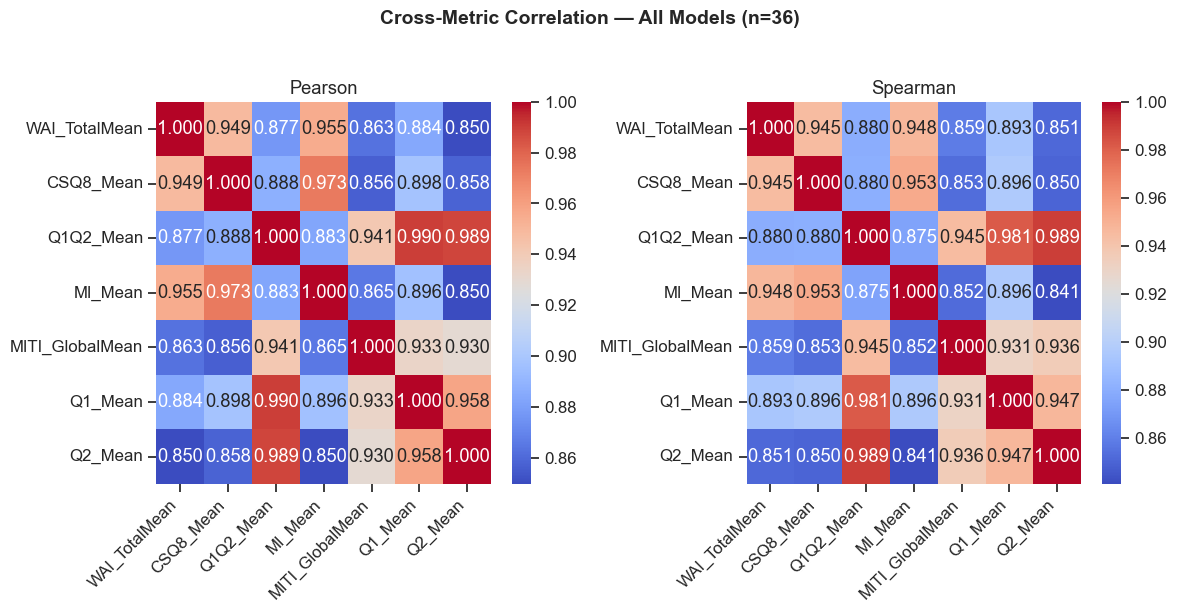

In [27]:
merged = build_merged_metrics(selected_test_cases)
if merged is not None:
    plot_correlation_heatmaps(merged, title=f"Cross-Metric Correlation — {selection_label}")
else:
    print("Need at least 2 metrics for correlation analysis.")


### 5.8 Metrics by Patient Cooperation Level

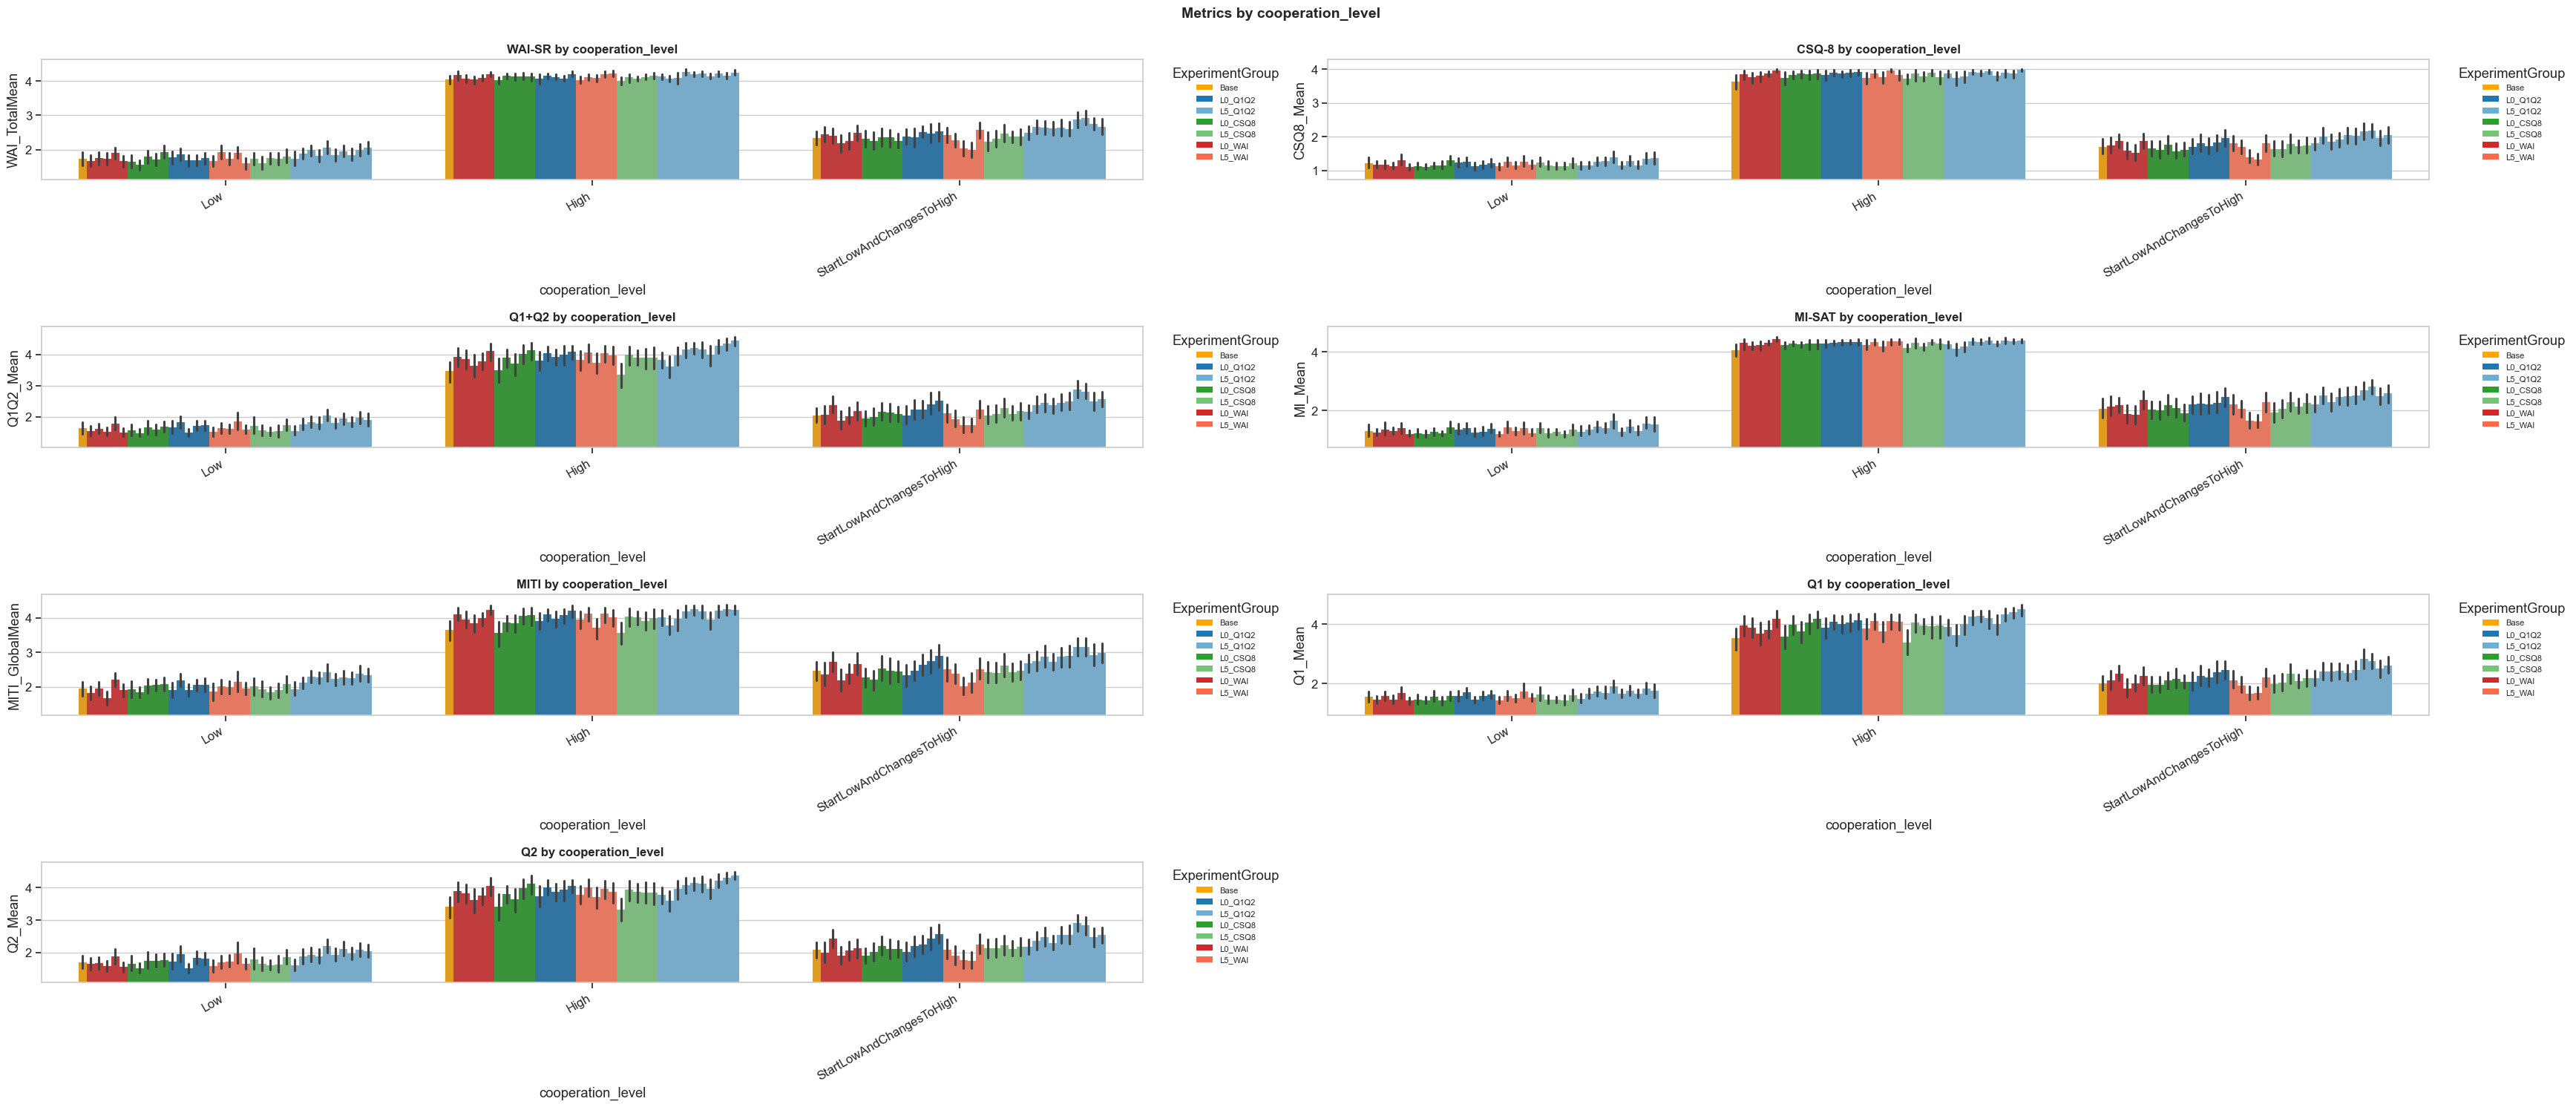

(<Figure size 3500x1500 with 8 Axes>,
 array([[<Axes: title={'center': 'WAI-SR by cooperation_level'}, xlabel='cooperation_level', ylabel='WAI_TotalMean'>,
         <Axes: title={'center': 'CSQ-8 by cooperation_level'}, xlabel='cooperation_level', ylabel='CSQ8_Mean'>],
        [<Axes: title={'center': 'Q1+Q2 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q1Q2_Mean'>,
         <Axes: title={'center': 'MI-SAT by cooperation_level'}, xlabel='cooperation_level', ylabel='MI_Mean'>],
        [<Axes: title={'center': 'MITI by cooperation_level'}, xlabel='cooperation_level', ylabel='MITI_GlobalMean'>,
         <Axes: title={'center': 'Q1 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q1_Mean'>],
        [<Axes: title={'center': 'Q2 by cooperation_level'}, xlabel='cooperation_level', ylabel='Q2_Mean'>,
         <Axes: >]], dtype=object))

In [28]:
metric_dfs  = {n: df for n, df, _ in iter_metric_cases(selected_test_cases)}
metric_cols = {n: c  for n, _, c  in iter_metric_cases(selected_test_cases)}
plot_metrics_by_patient_characteristic(
    metric_dfs, metric_cols, "cooperation_level",
    palette=ctx.experiment_palette, model_palette=ctx.model_palette,
    figsize=(35, 15), ylim="auto", ctx=ctx,
)


### 5.9 Conversation Length

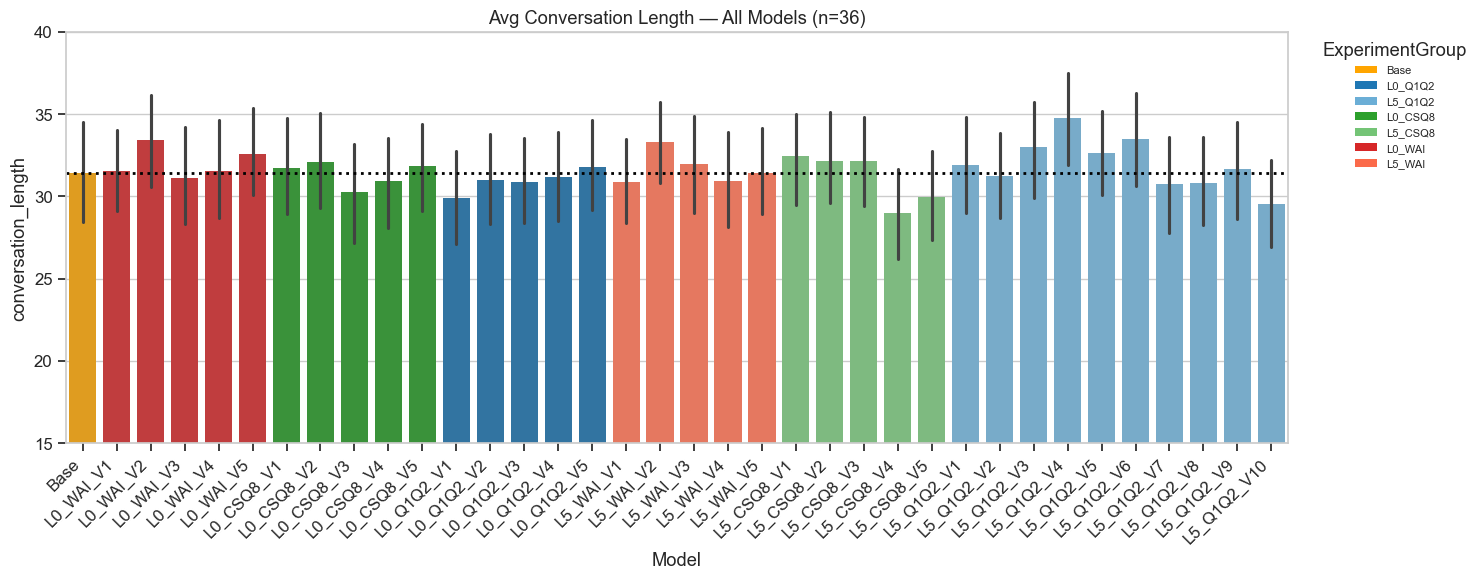

(<Figure size 1500x600 with 1 Axes>,
 <Axes: title={'center': 'Avg Conversation Length — All Models (n=36)'}, xlabel='Model', ylabel='conversation_length'>)

In [29]:
present = set(selected_combined_data["Model"].astype(str).unique())
order = [m for m in selected_model_order if m in present]
plot_metric_by_model(
    selected_combined_data, metric="conversation_length",
    title=f"Avg Conversation Length — {selection_label}",
    ylim=(15, 40), model_order=order, ctx=ctx,
)


### 5.10 Session Ending Patterns

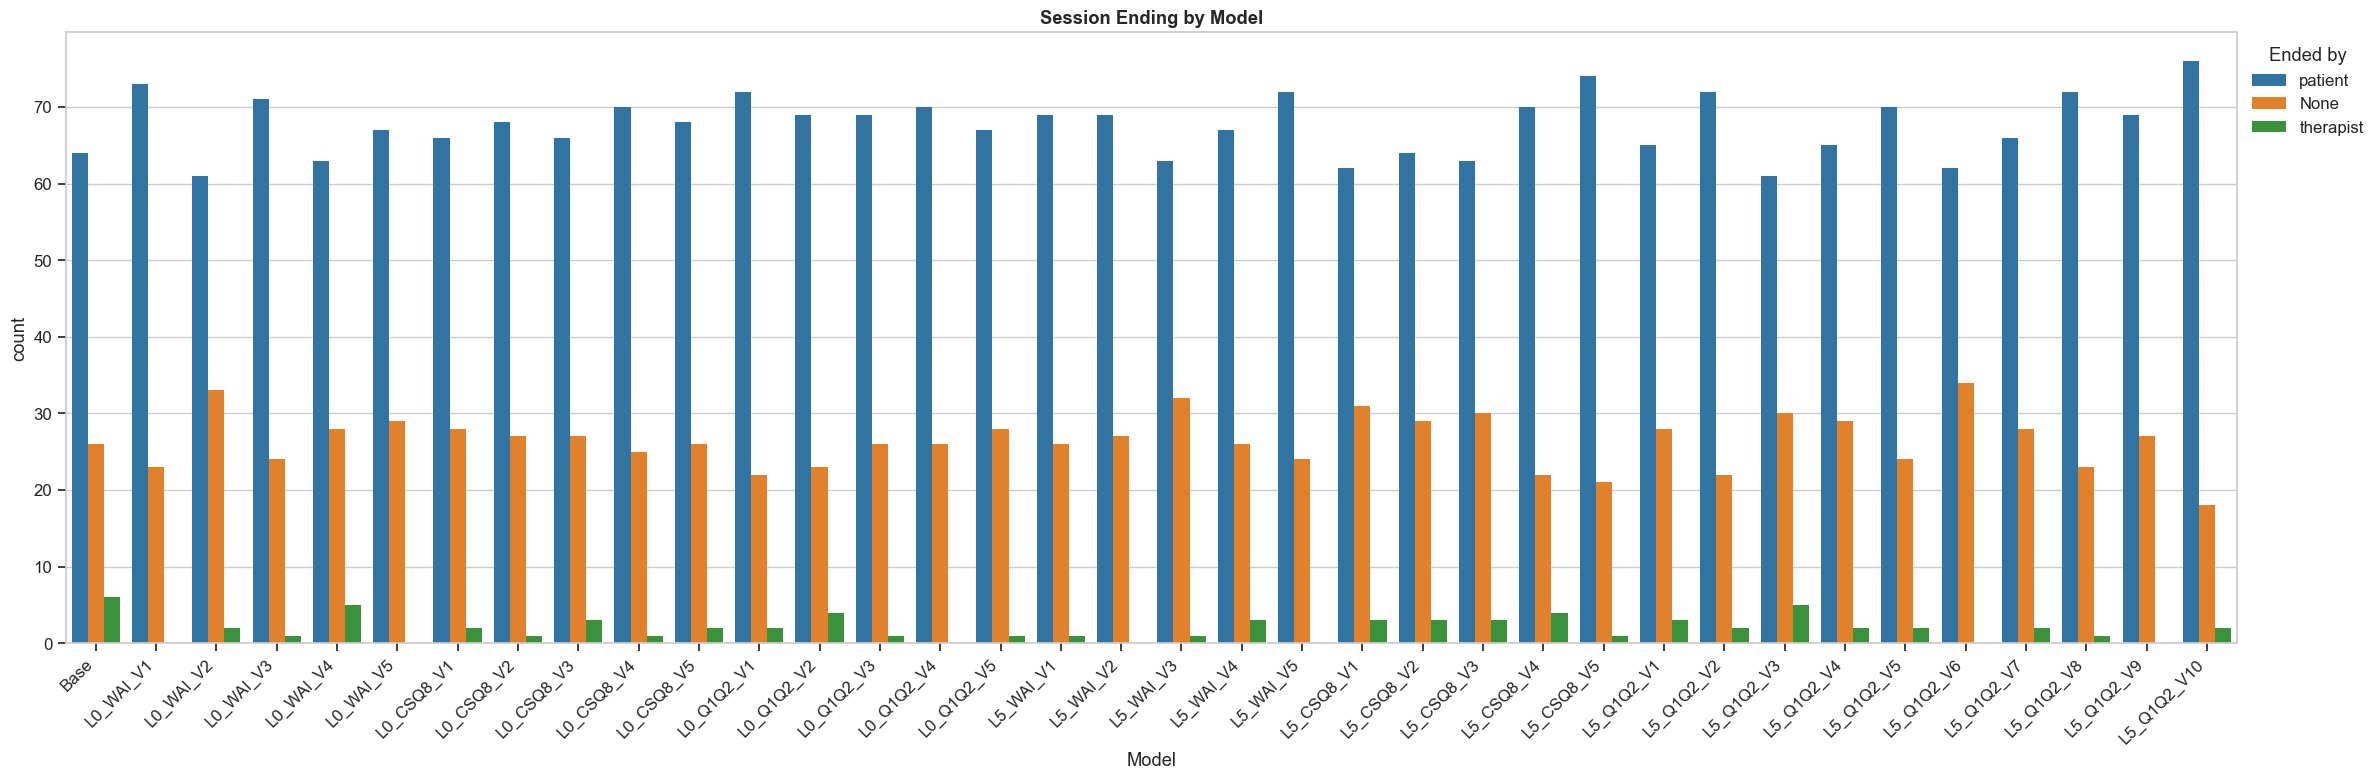

(<Figure size 2400x800 with 1 Axes>,
 <Axes: title={'center': 'Session Ending by Model'}, xlabel='Model', ylabel='count'>)

In [30]:
present = set(selected_combined_data["Model"].astype(str).unique())
order = [m for m in selected_model_order if m in present]
plot_session_ending(
    selected_combined_data, palette=ctx.experiment_palette,
    figsize=(24, 8), model_order=order,
)
